# DỰ ÁN 1: PHÂN TÍCH VÀ DỰ BÁO NHIỆT ĐỘ TOÀN CẦU (GLOBAL CLIMATE CHANGE)

## 1. Thông tin dự án
* **Tên đề tài:** Phân tích biến động và dự báo nhiệt độ cục bộ tại các thành phố lớn trong 20 năm tới.
* **Bộ dữ liệu:** Climate Change: Earth Surface Temperature Data (Nguồn: Kaggle).
* **Mục tiêu:** Xử lý dữ liệu lịch sử thời tiết, thực hiện nội suy lấp đầy khoảng trống và áp dụng mô hình Machine Learning dự báo xu hướng.

## 2. Danh sách thành viên nhóm
1. Nguyễn Minh Khôi  - PS48256 - xữ lí dữ liệu
2. Trần Văn NAm - PS48947 - Mô hình & Huấn luyện (Machine Learning)
3. Vũ Quanh Khải - PS47935 - Trực quan hóa & Ứng dụng (AI Product)

In [12]:
import os
import pandas as pd

# Đường dẫn dữ liệu local trong workspace
file_path = '../data/raw/GlobalLandTemperaturesByCity.csv'
print('Data file exists:', os.path.exists(file_path), file_path)

# Nạp dữ liệu và chuyển cột ngày về kiểu datetime
df = pd.read_csv(file_path, parse_dates=['dt'], low_memory=False)

# Hiển thị vài dòng đầu tiên để xác nhận dữ liệu
df.head()

Data file exists: True ../data/raw/GlobalLandTemperaturesByCity.csv


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


Đã tạo xong các biến Year, Month, Season!


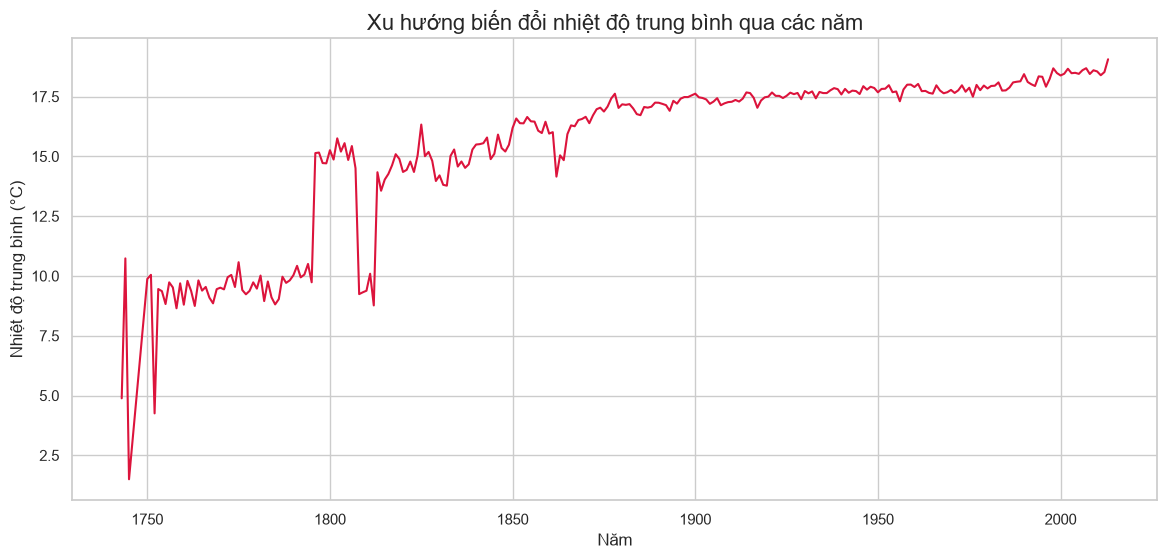

C:\Users\User\AppData\Local\Temp\ipykernel_2860\1290117922.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='AverageTemperature',


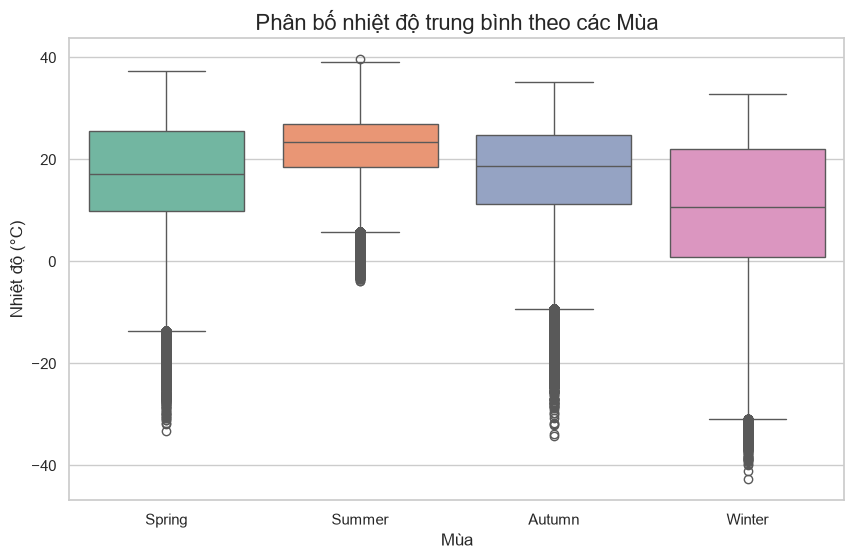

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. ĐỌC DỮ LIỆU
file_path = '../data/raw/GlobalLandTemperaturesByCity.csv'
df = pd.read_csv(file_path, parse_dates=['dt'])

# 2. FEATURE ENGINEERING (Tạo biến Năm, Tháng, Mùa)
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['Month'].apply(get_season)
print("Đã tạo xong các biến Year, Month, Season!")

# 3. EDA (Vẽ biểu đồ)
# Biểu đồ 1: Xu hướng theo năm
yearly_temp = df.groupby('Year')['AverageTemperature'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_temp, x='Year', y='AverageTemperature', color='crimson')
plt.title('Xu hướng biến đổi nhiệt độ trung bình qua các năm', fontsize=16)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Nhiệt độ trung bình (°C)', fontsize=12)
plt.show()

# Biểu đồ 2: Phân bố theo mùa
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Season', y='AverageTemperature', 
            order=['Spring', 'Summer', 'Autumn', 'Winter'], palette='Set2')
plt.title('Phân bố nhiệt độ trung bình theo các Mùa', fontsize=16)
plt.xlabel('Mùa', fontsize=12)
plt.ylabel('Nhiệt độ (°C)', fontsize=12)
plt.show()